In [6]:
import tifffile as tiff
import rasterio
import numpy as np
import matplotlib.pyplot as plt
from eva_losses import eva_metrics,eva_dice, true_positives, false_positives, true_negatives, false_negatives, eva_sensitivity, eva_specificity, eva_miou

#Etablir path to the input and output files
input = 'fichier_avec_region_seulement/ground_truth_2018_1km_6294_463'
pred_segmentation = 'fichier_avec_region_seulement/prediction_seg_2018_1km_6294_463_only_region_to_segment'

### Importer et visualiser l'image de segmentation (output du modèle)

In [7]:
# Ouvrir image de segmentation (pred_segmentation)
with rasterio.open(pred_segmentation+'.tif') as src:
    print(f"Dimensions: {src.shape}")  
    print(f"Nombre de bandes : {src.count}")
    segmentation = src.read(1)

# Statistiques de l’image
print(f"Min: {segmentation.min()}, Max: {segmentation.max()}, Moyenne: {segmentation.mean()}")

# Vérifier qu'il y a seulement des 0 ou des 1 dans l'image
unique_values = np.unique(segmentation)
if np.array_equal(unique_values, [0, 1]):
    print("L'image contient uniquement des 0 et des 1.")
else:
    print(f"L'image contient d'autres valeurs : {unique_values}")

# Compter le nombre de pixels de chaque classe
unique, counts = np.unique(segmentation, return_counts=True)
print("Nombre de pixels par classe :")
for value, count in zip(unique, counts):
    print(f"Classe {value}: {count} pixels")

# Normaliser entre 0 et 255
segmentation_normalized = (segmentation - segmentation.min()) / (segmentation.max() - segmentation.min()) * 255
segmentation_normalized = segmentation_normalized.astype(np.uint8)

# Sauvegarder l'image normalisée
with rasterio.open(pred_segmentation+'_fixed.tif', "w", driver="GTiff",
                   height=segmentation.shape[0], width=segmentation.shape[1],
                   count=1, dtype=segmentation_normalized.dtype) as dst:
    dst.write(segmentation_normalized, 1)

Dimensions: (1271, 1014)
Nombre de bandes : 1
Min: 0, Max: 1, Moyenne: 0.28050409918109487
L'image contient uniquement des 0 et des 1.
Nombre de pixels par classe :
Classe 0: 927282 pixels
Classe 1: 361512 pixels


c:\Users\olgaz\anaconda3\Lib\site-packages\rasterio\__init__.py:378: NotGeoreferencedWarning: Dataset has no geotransform, gcps, or rpcs. The identity matrix will be returned.
  dataset = writer(


## Importer l'image de ground truth (labels)



In [8]:
# Ouvrir image de Ground Truth
with rasterio.open(input+'.png') as src:
    print(f"Dimensions: {src.shape}")  
    print(f"Nombre de bandes : {src.count}")
    ground_truth = src.read(1)

# Statistiques de l’image
print(f"Min: {ground_truth.min()}, Max: {ground_truth.max()}, Moyenne: {ground_truth.mean()}")

# Vérifier qu'il y a seulement des 0 ou des 1 dans l'image
unique_values = np.unique(ground_truth)
if np.array_equal(unique_values, [0, 1]):
    print("L'image contient uniquement des 0 et des 1.")
else:
    print(f"L'image contient d'autres valeurs : {unique_values}")

# Compter le nombre de pixels de chaque classe
unique, counts = np.unique(ground_truth, return_counts=True)
print("Nombre de pixels par classe :")
for value, count in zip(unique, counts):
    print(f"Classe {value}: {count} pixels")

# Normaliser entre 0 et 255
ground_truth_normalized = (ground_truth - ground_truth.min()) / (ground_truth.max() - ground_truth.min()) * 255
ground_truth_normalized = ground_truth_normalized.astype(np.uint8)

# Sauvegarder l'image normalisée
with rasterio.open(input+'_fixed.tif', "w", driver="GTiff",
                   height=ground_truth.shape[0], width=ground_truth.shape[1],
                   count=1, dtype=ground_truth_normalized.dtype) as dst:
    dst.write(ground_truth_normalized, 1)

Dimensions: (1271, 1014)
Nombre de bandes : 1
Min: 0, Max: 1, Moyenne: 0.3187701060060801
L'image contient uniquement des 0 et des 1.
Nombre de pixels par classe :
Classe 0: 877965 pixels
Classe 1: 410829 pixels


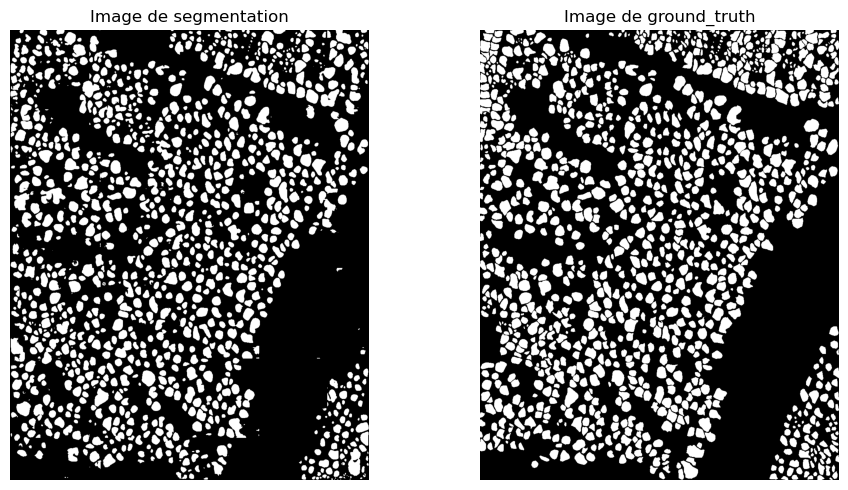

In [9]:
# Visualiser les deux images côte à côte
fig, axs = plt.subplots(1, 2, figsize=(10, 5))
axs[0].imshow(segmentation, cmap="gray")
axs[0].set_title("Image de segmentation")
axs[0].axis('off')

axs[1].imshow(ground_truth, cmap="gray")
axs[1].set_title("Image de ground_truth")
axs[1].axis('off')

plt.tight_layout()
plt.show()

## Test pour calculer une métrique

Accuracy: 0.8855433839698198, F1 Score: 0.809007938203462, Precision: 0.8641898470866803, Recall: 0.7604502116452344
Valeurs uniques dans ground_truth : [0 1]
Valeurs uniques dans segmentation : [0 1]
Valeurs uniques dans segmentation : [  0 255]
Matrice de confusion :
[[312415  49097]
 [ 98414 828868]]


Text(0.5, 1.0, 'Matrice de confusion')

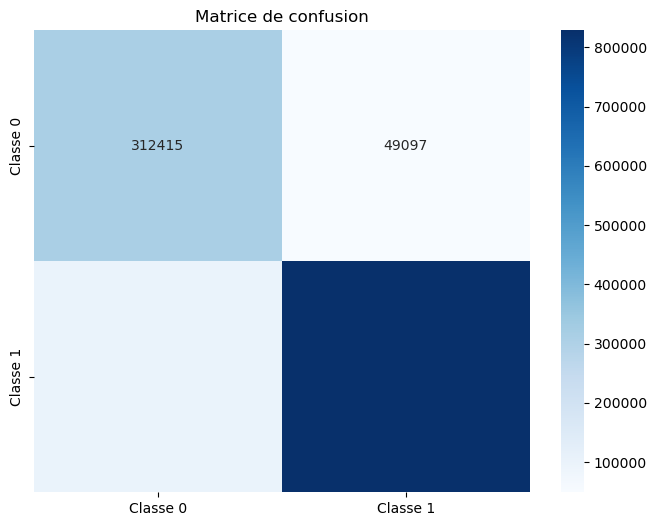

In [ ]:
acc, f1, precision, recall = eva_metrics(ground_truth, segmentation)
print(f"Accuracy: {acc}, F1 Score: {f1}, Precision: {precision}, Recall: {recall}")

#eva_acc(ground_truth, segmentation_normalized)##

# Valeurs uniques de ground_truth et segmentation
print("Valeurs uniques dans ground_truth :", np.unique(ground_truth))
print("Valeurs uniques dans segmentation :", np.unique(segmentation))

# Matrice de confusion
from eva_losses import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

# Calculer la matrice de confusion
cm = confusion_matrix(ground_truth, segmentation)
print("Matrice de confusion :")
print(cm)

# Visualiser la matrice de confusion
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['Classe 0', 'Classe 1'], yticklabels=['Classe 0', 'Classe 1'])
plt.title('Matrice de confusion')